# Karplus-Strong


Using delay-line inital conditions to "pluck" the string consisting of random numbers, or white noise. The inital shape of the string is obtained by adding the upper and lower delay lines, we also apply a low-pass filter by taking the average of adjacent samples to obtain:  $$y(n) = 0.5(y(n-N) + y(n-N-1))$$ where $N$ is the sample length. Pitch is determined by $$ f \approx fs / (N+0.5)$$ where $fs$ is the sample rate, set to $44100$ by standard. Without the 2-point average, a raw looped buffer is exactly $ fs/ N$.

In [1]:
%matplotlib inline
import numpy as np, wave, struct
import matplotlib.pyplot as plt
from IPython.display import display, Audio

In [2]:
fs = 44100 #sample rate
N = 100 # delay-line length
duration = 2.0

In [3]:
noise = np.random.uniform(-1,1, N) #White noise initial state
output = np.zeros(int(fs * duration))
output[0] = noise[0]
idx = 0
last = 0

for i in range(int(fs * duration)):
    output[i] = noise[idx]
    x = noise[idx]
    noise[idx] = 0.5 * (x + last)
    last = x 
    idx = (idx + 1) % N


In [4]:
def plot_waveform_spectrum(output, name = "output"):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    
    t_ms = np.arange(len(output)) / fs * 1000
    ax[0].plot(t_ms[:250], output[:250])
    ax[0].set_title(f"waveform - {name}")
    ax[0].set_xlabel('ms'); ax[0].set_ylabel('amp')
    
    X = np.abs(np.fft.rfft(output * np.hanning(len(output))))
    f = np.fft.rfftfreq(len(output), 1/fs)
    ax[1].plot(f, 20*np.log10(X/np.max(X) + 1e-9))
    ax[1].set_xlim(0, 6000); ax[1].set_ylim(-80, 2)
    ax[1].set_title(f"waveform - {name}"); ax[1].set_xlabel('Hz'); ax[1].set_ylabel('dB')
    
    plt.tight_layout(); plt.show()

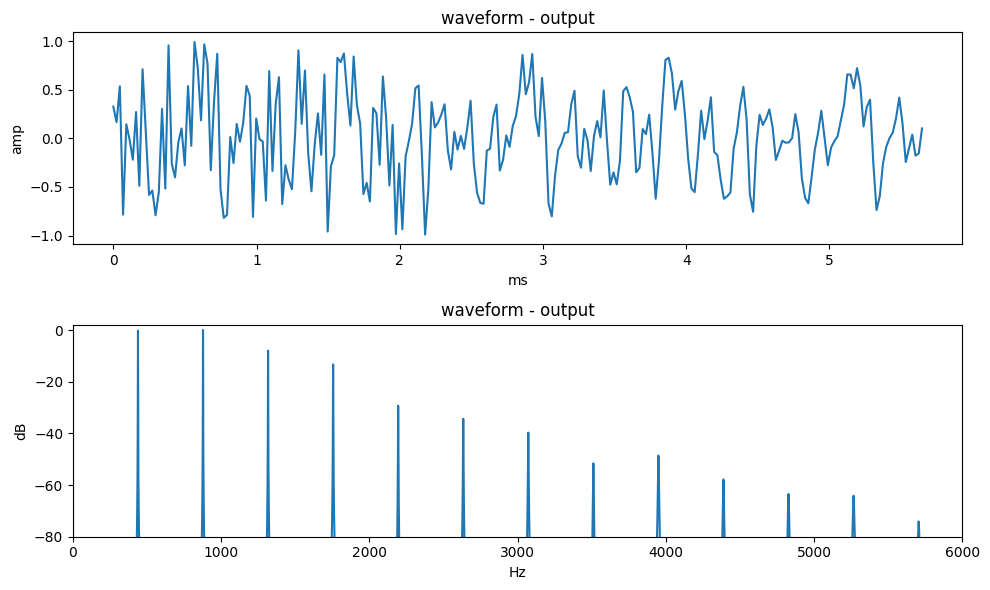

In [5]:
plot_waveform_spectrum(output)

In [6]:
Audio(output, rate = fs)

## The Pluck
The pluck is a triangular initial state at a point on the string. Each harmonic $n$ has a fixzed spatil shape along the string with nodes at $ x = L * k/n$. 

In [7]:
def pluck_string(beta, N = 100, duration = 2.0, fs = 44100, rho = 1.0 ):
    p = int(beta *N) 
    increasing = np.linspace(0, 1, p) 
    decreasing = np.linspace(1,0, N-p)
    noise = np.concatenate((increasing,decreasing))
                   
    output = np.zeros(int(fs * duration))
    output[0] = noise[0]
    idx = 0
    last = 0
    
    for i in range(int(fs * duration)):
        output[i] = noise[idx]
        x = noise[idx]
        noise[idx] = 0.5 * (x + last) * rho
        last = x 
        idx = (idx + 1) % N

    return output

In [8]:
output1 = pluck_string(0.5)
output2 = pluck_string(0.1)


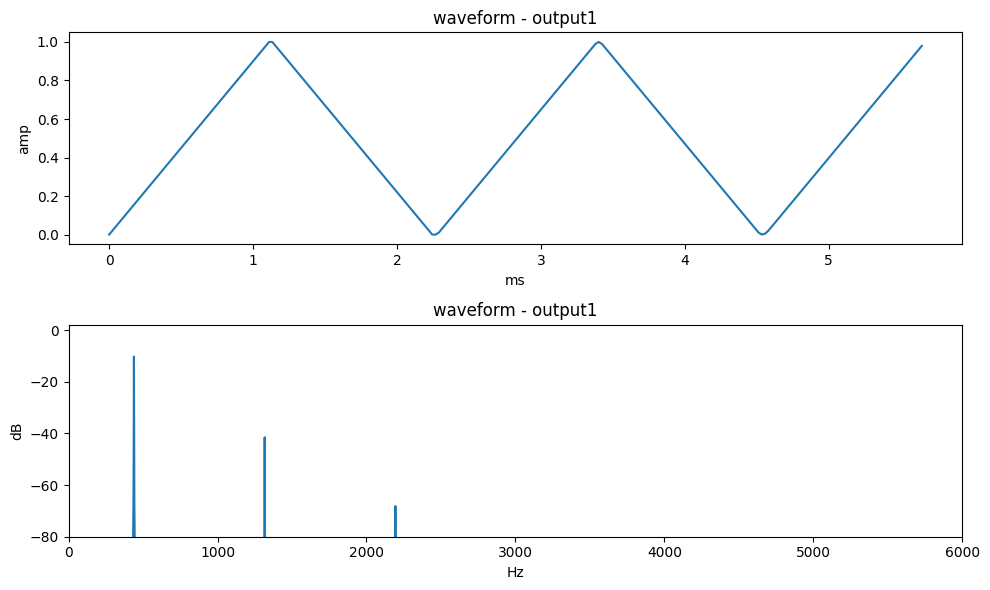

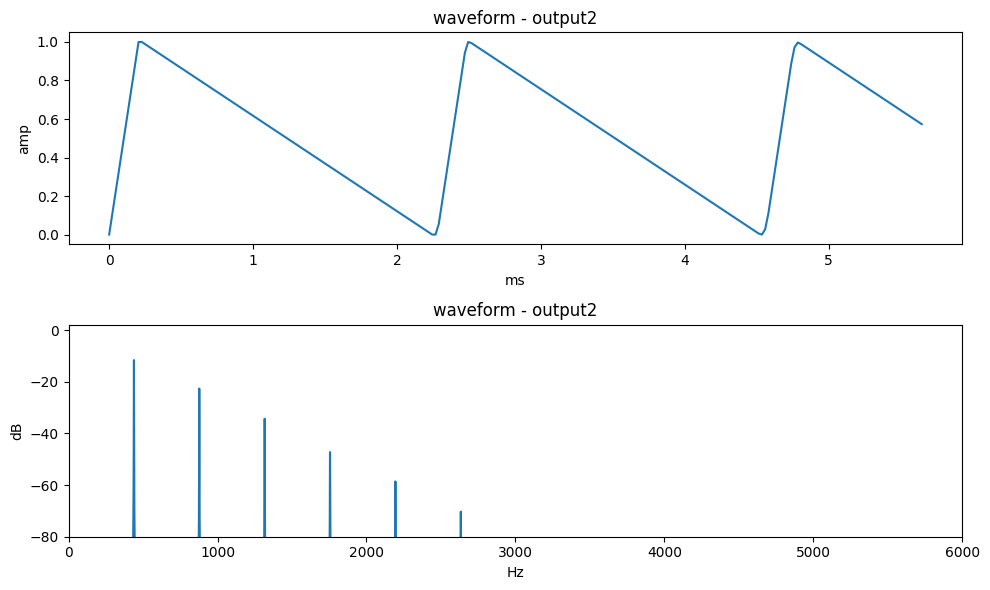

In [9]:
plot_waveform_spectrum(output1, "output1")
plot_waveform_spectrum(output2, "output2")

In [10]:
print("beta = 0.5 (center)"); display(Audio(output1, rate=fs))   # center pluck — hollow
print("beta = 0.1 (bridge)"); display(Audio(output2, rate=fs))   # bridge pluck — bright

beta = 0.5 (center)


beta = 0.1 (bridge)


## The Body (Acoustic)
Currently, we have just a string that displaces only a little of air so it is quiet. In an actual guitar, the string excites the air in the box of the guitar which resonates out the sound hole. We will use Finite Element to capture the characteristics of the body. 

**Finite Difference on a 1D stiff bar**
A string resists displacement by tension, a bar resists change by storing energy in its stiffness. This is a checkpoint in implimenting FE but will also be revisited in future explorations into percussion (xylophones, marimba, etc.)
$$ \text{string (tension): } \partial ^2 y / \partial t^2 = c^2 \cdot \partial ^2 y / \partial x^2 $$
$$ \text{bar (stiffness): } \partial ^2 y / \partial t^2 = -\kappa^2 \cdot \partial ^4 y / \partial x^4 $$
where $\kappa = EI / (\rho A)$ and $E$ is the Young's modulus, $I$ is the how the cross-ssection resists bending, $\rho$ is density and $A$ is area. The fourth derivative is the physical signature of bending and it makes the bar dispersive, high-frequency bending waves travels faster than low-frequency waves. Thus, stiff bars are inharmonic and its mode frequency ratios depend only on the boundary conditions.

By applying central difference twice: 
$$y''''_i = \frac{ y_{i-2} - 4y_{i-1} + 6y_i - 4y_{i+1} + y_{i+2} }{ h^4 }$$ 
The stiffness matrix $\mathcal{k}$ is coefficients of each point and the mass matrix $M$ is the identity matrix with equal point masses. So the bar's equation of motion is 
$$ ÿ  = -(\kappa ^2 / h^4) \cdot \mathcal{K} \cdot y $$
and the modes are the eigenvectors of $\mathcal{K}$:
$$ \mathcal{K} \phi = \lambda \phi $$
$$ \lambda = (\omega^2 h^4) / K^4$$
and mode frequency is 
$$ \omega = \sqrt{(\kappa ^ 2 / h^4) \cdot \lambda_i} $$ 

In [11]:
import scipy

In [12]:
M = 200 # number of points
K = np.zeros((M,M)) #stiffness matrix

#pinned (simply-supported) boundary rows to get the clean ratio 1 : 4 : 9 : 16 ...
K[0,0]=5;   K[0,1]=-4;   K[0,2]=1                       # first free point
K[1,0]=-4;  K[1,1]=6;    K[1,2]=-4;   K[1,3]=1          # second free point
K[M-2,M-1]=-4; K[M-2,M-2]=6; K[M-2,M-3]=-4; K[M-2,M-4]=1   # symmetric, far end
K[M-1,M-1]=5;  K[M-1,M-2]=-4; K[M-1,M-3]=1

#

#populating the internal points of the stiffness matrix with (1,-4,6,-4,1) along the diagonals of cols. i-2 ... i+2
for i in range(2,M-2,1):
    K[i][i-2] = 1
    K[i][i-1] = -4
    K[i][i] = 6
    K[i][i+1] = -4
    K[i][i+2] = 1

#Eigenproblem

evals, evecs = scipy.linalg.eigh(K) 
print("Expected ratios: 1, 4, 9, 16, 25")
np.sqrt(evals[:5]) / np.sqrt(evals[0]) 

Expected ratios: 1, 4, 9, 16, 25


array([ 1.        ,  3.99975568,  8.99853427, 15.99511463, 24.98778759])

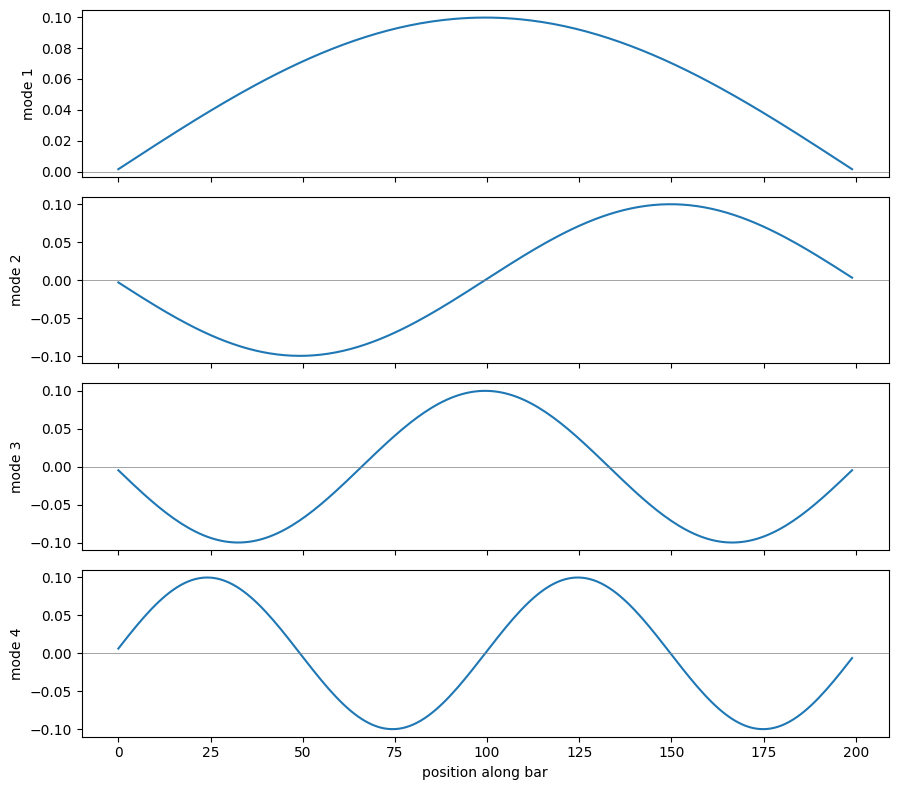

In [13]:
x = np.arange(M)
fig, ax = plt.subplots(4, 1, figsize=(9,8), sharex = True)
for k in range(4):
    ax[k].plot(x ,evecs[:,k])
    ax[k].axhline(0,color='gray',lw=0.5) # the flat rest position
    ax[k].set_ylabel(f'mode {k+1}')
ax[-1].set_xlabel('position along bar')
plt.tight_layout()
plt.show()

In [14]:
fs = 44100
duration = 2.0
t = np.arange(int(fs*duration))/fs
n_modes = 10
s = 15 #strike point
f_0 = 220.0

In [15]:
def bar_strike(decay = 300, s =15):
    freqs = f_0 * np.sqrt(evals) / np.sqrt(evals[0])
    
    y = np.zeros_like(t)
    for k in range(n_modes):
        amp = evecs[s,k] # how hard the strike excites mode k
        tau = 2.0 / (1+freqs[k]/decay) # higher modes decay faster, tune to taste
        y += amp * np.sin(2*np.pi*freqs[k]*t) * np.exp(-t/tau)
    
    y = y /np.max(np.abs(y)) # normalize
    return y

In [16]:
bar_sound = bar_strike()

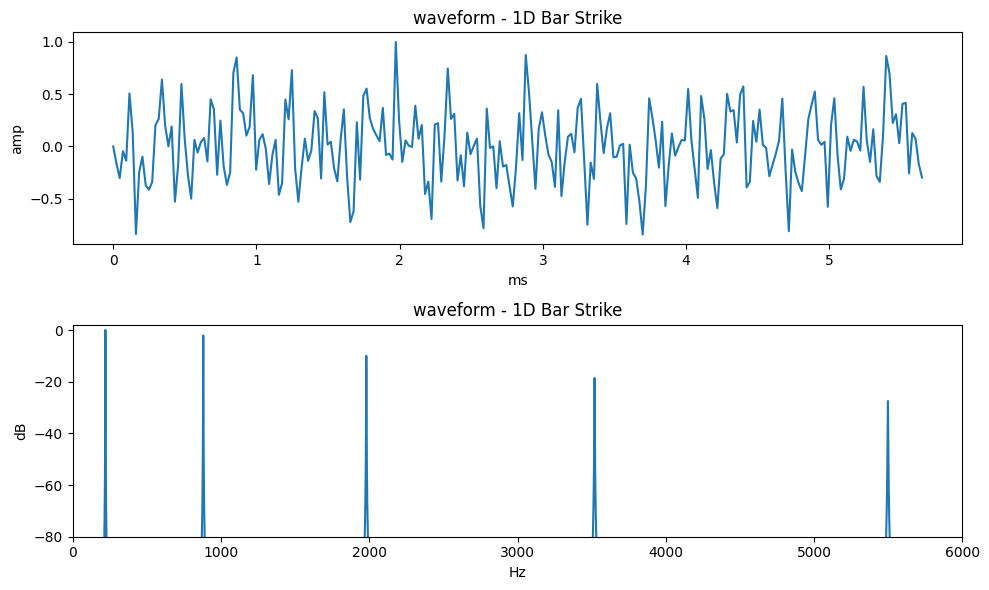

In [17]:
plot_waveform_spectrum(bar_sound, "1D Bar Strike")

In [18]:
print('s = 15')
display(Audio(bar_sound , rate = fs))
bar_sound_2 = bar_strike(300,30)
print ('s = 30')
display(Audio(bar_sound_2 , rate = fs))
bar_sound_3 = bar_strike(300,5)
print ('s = 5')
display(Audio(bar_sound_3 , rate = fs))

s = 15


s = 30


s = 5


**Ideal 2D Plate**
The 2D plate is governed by:
$$\partial ^2 w / \partial t^2 = (-D/\rho h) \cdot \nabla ^4 w $$
where $w(x,y)$ is the displacement of each point of the sheet and $\nabla^4$  is the biharmonic operator. The total pull of the forces are:
$$\frac{\partial^2 w}{\partial x^2} + \frac{\partial^2 w}{\partial y^2} = \frac{w[i+1,j] + w[i,j+1] - 4w[i,j] + w[i-1,j] + w[i,j-1]}{h^2} $$

In [19]:
Nx = Ny = 20
N = Nx * Ny 
def idx(i,j): return i * Ny + j # flattening

#2D Laplacian, -4 on the point, + 1 on each neightbor, using pinned boundary so neighbors off the grid are skipped
L = np.zeros((N,N))
for i in range(Nx):
    for j in range(Ny):
        p = idx(i,j)
        L[p, p] = -4
        if i > 0: L[p, idx(i-1,j)] = 1
        if i < Nx-1: L[p, idx(i+1,j)] = 1
        if j > 0: L[p,idx(i,j-1)] = 1
        if j < Ny-1: L[p,idx(i,j+1)] = 1
#Plate = Laplacian squared
K = L @ L

# modes
evals, evecs = scipy.linalg.eigh(K)
print(np.sqrt(evals[:8]) / np.sqrt(evals[0])) # Expected: ~[1,2.5,2.5,4,5,5,6.5,6.5]

[1.         2.48883083 2.48883083 3.97766165 4.93323446 4.93323446
 6.42206528 6.42206528]


In [30]:
def plate_strike(decay = 300, sx = 10, sy = 10, lx = 10, ly = 10): #sx, sy represent strike point. lx,ly represent listening point 
    freqs = f_0 * np.sqrt(evals) / np.sqrt(evals[0])
    y = np.zeros_like(t)
    for k in range(n_modes):
        amp = evecs[idx(sx,sy),k] * evecs[idx(lx,ly),k] # how hard the strike excites mode k
        tau = 2.0 / (1+freqs[k]/decay) # higher modes decay faster, tune to taste
        y += amp * np.sin(2*np.pi*freqs[k]*t) * np.exp(-t/tau)
    
    y = y /np.max(np.abs(y)) # normalize
    return y

In [31]:
plate_sound_1 = plate_strike()

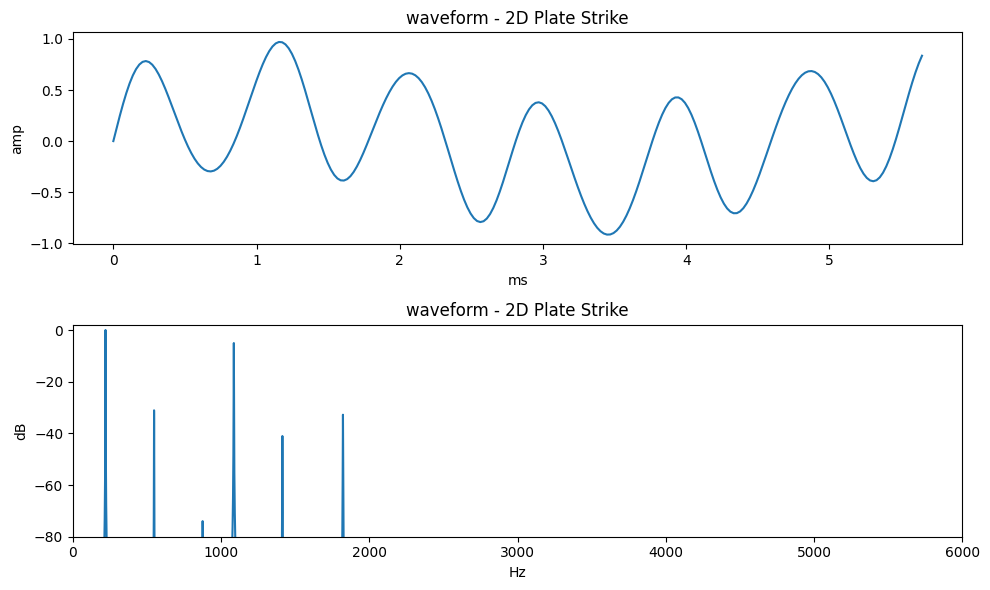

In [32]:
plot_waveform_spectrum(plate_sound_1, "2D Plate Strike")

In [35]:
print('s = 10,10')
display(Audio(bar_sound , rate = fs))
plate_strike_2 = plate_strike(300,5,10, 5, 10)
print('s = 5,10')
display(Audio(plate_strike_2 , rate = fs))
plate_strike_3 = plate_strike(300,5,20, 10,10)
print('s = 5,20')
display(Audio(plate_strike_3 , rate = fs))

s = 10,10


s = 5,10


s = 5,20


**Real Block, Guitar Body**  

Right now there is a pair of $2.5$ which are degenerate because the isotropic biharmonic is 
$$ \frac{\partial^2 w}{\partial x^2} + \frac{\partial^2 w}{\partial x^2} = \frac{\partial w^4}{\partial x^4} + 2 \frac{\partial^4 w}{\partial x^2 \partial y^2 } + \frac{\partial^4 w}{\partial y^4}  $$
So x,y enters identically and direction is lost. 
Wood is orthotropic meaning it is stiffer along the grain than across it. So the two directions get different bending rigidites $D_x \neq D_y$ so the plate operator becomes:
$$ D_x \partial^4 _x + 2 H \partial^2 _x \partial ^2 _y + D_y \partial ^4_y $$
This breaks the symmetry and the degenerate pair splits. The mode that bends more along the stiff direction rises in pitch faster than its partner. Squaring the anisotropic laplacian gives the orthotropic plate:
$$(a_x \partial _{xx} + a_y\partial_{yy})^2 = a^2_x \partial_x^4 + 2a_xa_y \partial^2_x \partial^2_y + a^2_y \partial^4_y $$
with $D_x = ax^2$ and $D_y = ay^2$ and cross term $H = \sqrt{D_x D_y}$ 

In [53]:
def orthotropic_plate(ax = 4 , ay = 1): #ax = 1, ay =1 should reproduce ideal
    Nx = Ny = 20
    N = Nx * Ny 
    def idx(i,j): return i * Ny + j # flattening
    
    #2D Anisotropic Laplacian
    L_a = np.zeros((N,N))
    for i in range(Nx):
        for j in range(Ny):
            p = idx(i,j)
            L_a[p, p] = -(2*ax + 2*ay)
            if i > 0: L_a[p, idx(i-1,j)] = ax
            if i < Nx-1: L_a[p, idx(i+1,j)] = ax
            if j > 0: L_a[p,idx(i,j-1)] = ay
            if j < Ny-1: L_a[p,idx(i,j+1)] = ay
    #Plate = Laplacian squared
    K = L_a @ L_a
    
    # modes
    evals, evecs = scipy.linalg.eigh(K)
    print(np.sqrt(evals[:8]) / np.sqrt(evals[0])) 
    return K, evals, evecs

In [54]:
plate1, plate1Evals, plate1Evecs = orthotropic_plate()

[1.         1.59553233 2.57329378 3.38212932 3.91144278 3.97766165
 4.95542311 5.58008729]


In [66]:
def real_plate_strike(K, evals, evecs, decay = 300, sx = 10, sy = 10, lx = 10, ly = 10): #sx, sy represent strike point. lx,ly represent listening point 
    freqs = f_0 * np.sqrt(evals) / np.sqrt(evals[0])
    y = np.zeros_like(t)
    for k in range(n_modes):
        amp = evecs[idx(sx,sy),k] * evecs[idx(lx,ly),k] # how hard the strike excites mode k
        tau = 2.0 / (1+freqs[k]/decay) # higher modes decay faster, tune to taste
        y += amp * np.sin(2*np.pi*freqs[k]*t) * np.exp(-t/tau)
    
    y = y /np.max(np.abs(y)) # normalize
    return y

In [67]:
real_plate_sound_1 = real_plate_strike(plate1, plate1Evals, plate1Evecs)

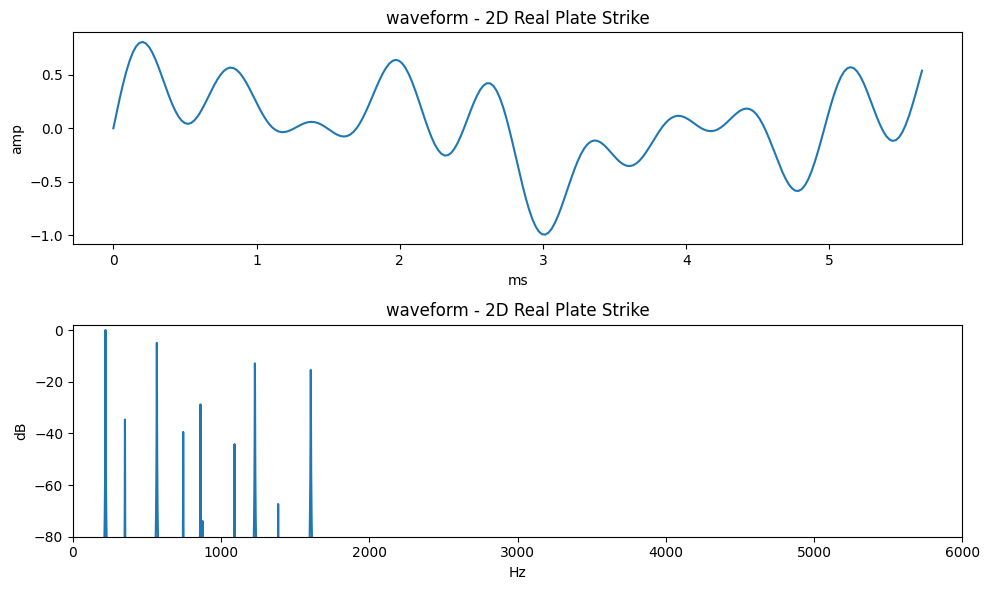

In [68]:
plot_waveform_spectrum(real_plate_sound_1, "2D Real Plate Strike")

In [69]:
display(Audio(real_plate_sound_1 , rate = fs))

**A guitar is a linear chain of blocks**  

The string is an oscillator and the body is a filters the colors the stringss sound with its own resonances. Both are linear and time-invariant so the whole body can be folded into a single fixed operation.

Reference: https://ccrma.stanford.edu/~jos/pasp/Karplus_Strong_Algorithm.html